<a href="https://colab.research.google.com/github/PritwishSaha/STUDENT-PLACEMENT-ANALYSIS/blob/main/student_performence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
import scipy.stats as stats
print("done")

done


In [2]:
from google.colab import files
a = files.upload()

Saving Student_Performance.csv to Student_Performance.csv


In [3]:
df = pd.read_csv('Student_Performance.csv')
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [4]:
df.shape

(10000, 6)

In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [7]:
df.duplicated().sum()

np.int64(127)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

In [11]:
  df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


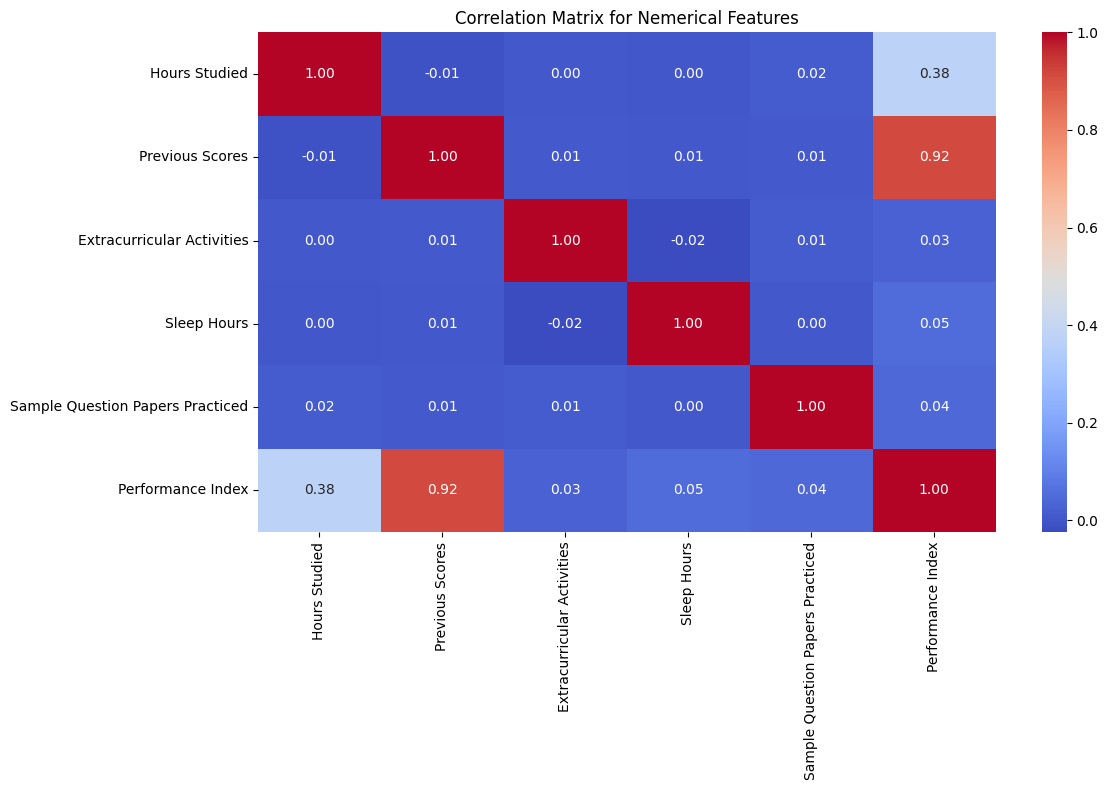

In [12]:
correlation_matrix = df.corr(numeric_only= True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Nemerical Features')
plt.tight_layout()
plt.show()

In [15]:
df.drop(columns=['Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced'])

,Hours Studied,Previous Scores,Performance Index
0,7,99,91.0
1,4,82,65.0
2,8,51,45.0
3,5,52,36.0
4,7,75,66.0
...,...,...,...
9995,1,49,23.0
9996,7,64,58.0
9997,6,83,74.0
9998,9,97,95.0


In [16]:
print(df.columns)

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


In [17]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [18]:
df.drop(columns=['Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced'])

,Hours Studied,Previous Scores,Performance Index
0,7,99,91.0
1,4,82,65.0
2,8,51,45.0
3,5,52,36.0
4,7,75,66.0
...,...,...,...
9995,1,49,23.0
9996,7,64,58.0
9997,6,83,74.0
9998,9,97,95.0


In [19]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [20]:
df.head()

,Hours Studied,Previous Scores,Performance Index
0,7,99,91.0
1,4,82,65.0
2,8,51,45.0
3,5,52,36.0
4,7,75,66.0
...,...,...,...
9995,1,49,23.0
9996,7,64,58.0
9997,6,83,74.0
9998,9,97,95.0


In [21]:
 y = df['Performance Index']
 x = df.drop('Performance Index', axis=1)
 scaler = StandardScaler()
 x_scaled = scaler.fit_transform(x)
 x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.1, random_state=42)
 print(x_train.shape)
 print(x_test.shape)
 print(y_train.shape)
 print(y_test.shape)

(8885, 5)
(988, 5)
(8885,)
(988,)


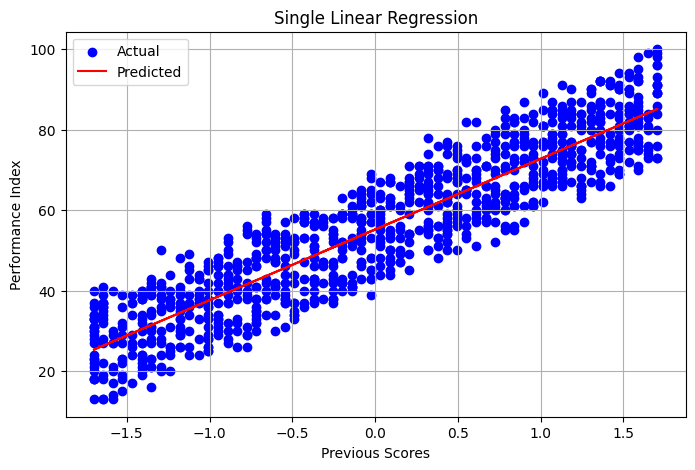

Single Linear Regression R-squared: 0.8390
Single Linear Regression Mean Squared Error: 59.9961


In [24]:
from sklearn.linear_model import LinearRegression
x_single_train = x_train[:, [1]]
x_single_test = x_test[:, [1]]
lr_single = LinearRegression()
lr_single.fit(x_single_train, y_train)
y_pred_single = lr_single.predict(x_single_test)
plt.figure(figsize=(8, 5))
plt.scatter(x_single_test, y_test, color='blue', label='Actual')
plt.plot(x_single_test, y_pred_single, color='red', label='Predicted')
plt.title('Single Linear Regression')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.legend()
plt.grid(True)
plt.show()
r2_single = r2_score(y_test, y_pred_single)
mse_single = mean_squared_error(y_test, y_pred_single)
print(f"Single Linear Regression R-squared: {r2_single:.4f}")
print(f"Single Linear Regression Mean Squared Error: {mse_single:.4f}")

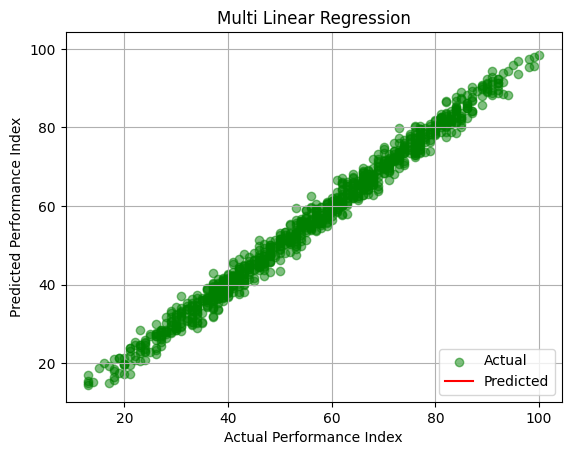

In [25]:
lr_multi = LinearRegression()
lr_multi.fit(x_train, y_train)
y_pred_multi = lr_multi.predict(x_test)
plt.scatter(y_test, y_pred_multi,alpha= 0.5, color='green', label='Actual')
plt.plot(y_test.min(), y_test.max(), color='red', label='Predicted')
plt.title('Multi Linear Regression')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.legend()
plt.grid(True)
plt.show()
r2_multi = r2_score(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)

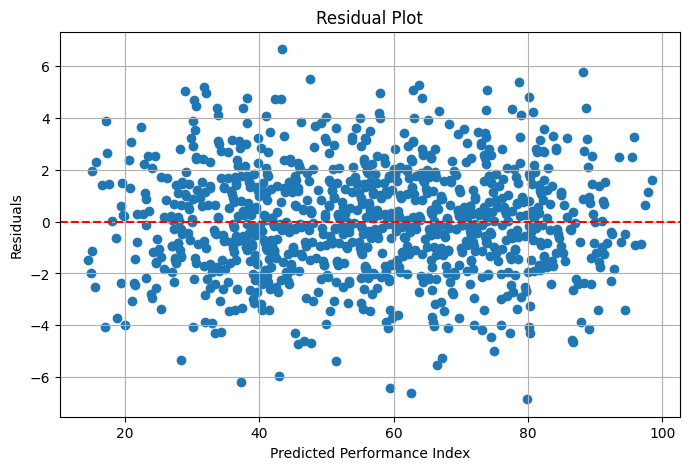

In [29]:
residuals = y_test - y_pred_multi

plt.figure(figsize=(8,5))
plt.scatter(y_pred_multi, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Performance Index")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


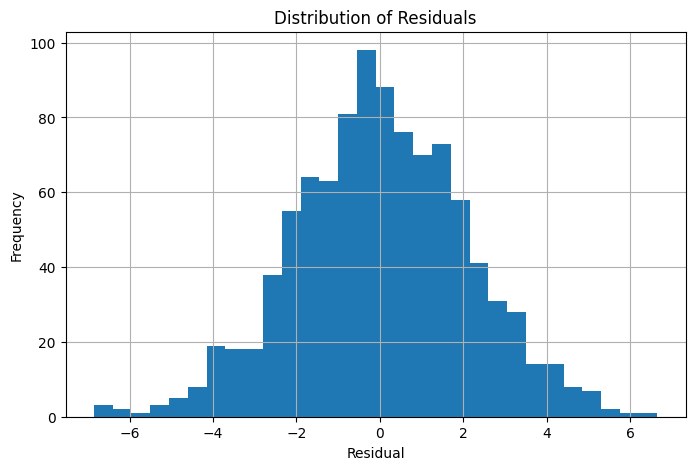

In [30]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [32]:
new_student = pd.DataFrame(
    [[7, 85, 1, 7, 5]],
    columns=x.columns
)

new_student_scaled = scaler.transform(new_student)

prediction = lr_multi.predict(new_student_scaled)

print("Predicted Performance Index:", prediction[0])

Predicted Performance Index: 77.38985634919922


In [33]:
import joblib

joblib.dump(lr_multi, "student_performance_model.pkl")

['student_performance_model.pkl']